In [2]:
# Core imports for the whole lab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
np.random.seed(42)
df = sns.load_dataset('tips')
print('Loaded tips dataset:', df.shape)
df.head()

Loaded tips dataset: (244, 7)


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:

#1A. NUMERICAL vs CATEGORICAL COLUMNS
print(df.dtypes)
numerical   = df.select_dtypes(include='number').columns.tolist()
categorical = df.select_dtypes(exclude='number').columns.tolist()
print('\nNumerical  :', numerical)
print('Categorical:', categorical)

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Numerical  : ['total_bill', 'tip', 'size']
Categorical: ['sex', 'smoker', 'day', 'time']


In [4]:
#  1B. WHICH STATISTIC FITS WHICH TYPE
print('Mean total_bill:', round(df['total_bill'].mean(), 2))
print('Day value counts:')
print(df['day'].value_counts())

Mean total_bill: 19.79
Day value counts:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64


In [5]:
# LAB EXERCISE 1 - Classify the columns

# 1. Numerical and categorical columns
numerical = df.select_dtypes(include="number").columns.tolist()
categorical = df.select_dtypes(exclude="number").columns.tolist()

print("Numerical columns:", numerical)
print("Categorical columns:", categorical)

# 2. Mean of tip
print("Mean of tip:", df["tip"].mean())

# 3. Value counts of sex
print("Sex value counts:")
print(df["sex"].value_counts())

Numerical columns: ['total_bill', 'tip', 'size']
Categorical columns: ['sex', 'smoker', 'day', 'time']
Mean of tip: 2.99827868852459
Sex value counts:
sex
Male      157
Female     87
Name: count, dtype: int64


In [ ]:

# 2A. MEAN, MEDIAN, MODE


col = df['total_bill']
print('Mean   :', round(col.mean(), 2))
print('Median :', round(col.median(), 2))
print('Mode   :', round(col.mode()[0], 2))

In [ ]:

# 2B. WHEN MEAN AND MEDIAN DISAGREE (skew)


# A right-skewed column drags the mean above the median
print('mean > median ?', col.mean() > col.median(), '-> right-skewed')

plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)
plt.axvline(col.mean(),   color='red',   label='mean')
plt.axvline(col.median(), color='green', label='median')
plt.legend(); plt.title('total_bill: mean vs median'); plt.show()

Mean   : 3.0
Median : 2.9
Mode   : 2.0
Mean > Median: True


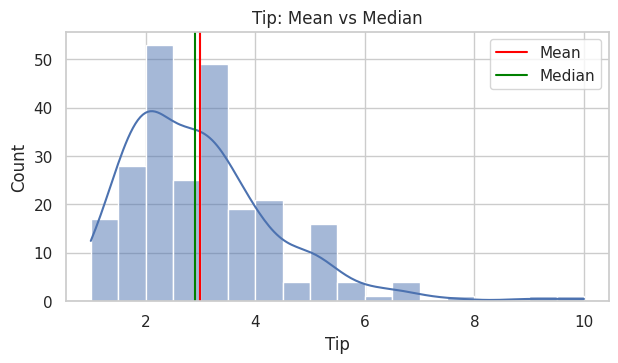

In [7]:
# LAB EXERCISE 2 - Central Tendency

col = df["tip"]


# Mean, Median and Mode
print("Mean   :", round(col.mean(), 2))
print("Median :", round(col.median(), 2))
print("Mode   :", round(col.mode()[0], 2))

# Check for right skew
print("Mean > Median:", col.mean() > col.median())

# Histogram with mean and median
plt.figure(figsize=(7, 3.5))
sns.histplot(col, kde=True)

plt.axvline(col.mean(), color="red", label="Mean")
plt.axvline(col.median(), color="green", label="Median")

plt.legend()
plt.title("Tip: Mean vs Median")
plt.xlabel("Tip")
plt.show()


In [8]:

# 🔹 3A. RANGE, VARIANCE, STANDARD DEVIATION

col = df['total_bill']
print('Range :', round(col.max() - col.min(), 2))
print('Var   :', round(col.var(), 2))
print('Std   :', round(col.std(), 2))

Range : 47.74
Var   : 79.25
Std   : 8.9


In [9]:

# 🔹 3B. QUARTILES & THE INTERQUARTILE RANGE (IQR)


q1, q3 = col.quantile(0.25), col.quantile(0.75)
iqr = q3 - q1
print('Q1 (25%):', round(q1, 2))
print('Q3 (75%):', round(q3, 2))
print('IQR     :', round(iqr, 2), '-> spread of the middle 50% (robust to outliers)')

Q1 (25%): 13.35
Q3 (75%): 24.13
IQR     : 10.78 -> spread of the middle 50% (robust to outliers)


In [10]:
# LAB EXERCISE 3 - Spread

col = df["tip"]

# 1. Range, Variance and Standard Deviation
print("Range:", round(col.max() - col.min(), 2))
print("Variance:", round(col.var(), 2))
print("Standard Deviation:", round(col.std(), 2))

# 2. Quartiles and IQR
q1 = col.quantile(0.25)
q3 = col.quantile(0.75)
iqr = q3 - q1

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))

# 3. IQR is more robust to outliers
# because it uses the middle 50% of the data.

Range: 9.0
Variance: 1.91
Standard Deviation: 1.38
Q1: 2.0
Q3: 3.56
IQR: 1.56


In [11]:

# 🔹 4A. FIVE-NUMBER SUMMARY (min, Q1, median, Q3, max)


col = df['total_bill']
five = col.describe()[['min', '25%', '50%', '75%', 'max']]
print(five)

print('\nSkewness:', round(col.skew(), 3))

min     3.0700
25%    13.3475
50%    17.7950
75%    24.1275
max    50.8100
Name: total_bill, dtype: float64

Skewness: 1.133


In [ ]:

# 🔹 4B. BOX PLOT (a picture of the five-number summary)
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df['total_bill'])
plt.title('Box plot of total_bill'); plt.show()

Five-number summary:
min     1.0000
25%     2.0000
50%     2.9000
75%     3.5625
max    10.0000
Name: tip, dtype: float64

Skewness: 1.465


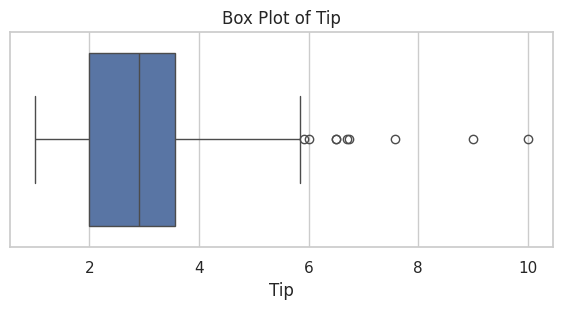

In [12]:
# LAB EXERCISE 4 - Five-number summary & box plot

# 1. Five-number summary
col = df["tip"]

five = col.describe()[["min", "25%", "50%", "75%", "max"]]

print("Five-number summary:")
print(five)

# 2. Skewness
print("\nSkewness:", round(col.skew(), 3))

# Positive = right-skewed
# Negative = left-skewed
# Near 0 = approximately symmetric

# 3. Box plot
plt.figure(figsize=(7, 2.8))
sns.boxplot(x=df["tip"])
plt.title("Box Plot of Tip")
plt.xlabel("Tip")
plt.show()

In [14]:

# 🔹 5A. CORRELATION between numerical columns
corr = df.corr(numeric_only=True)
print(corr.round(2))
print('\ntotal_bill vs tip:', round(corr.loc['total_bill', 'tip'], 2), '-> strong positive')

            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00

total_bill vs tip: 0.68 -> strong positive


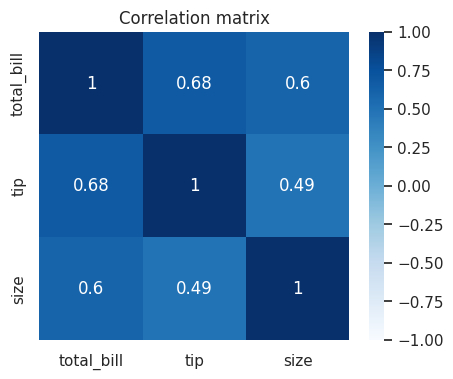

In [13]:

# 🔹 5B. VISUALISE THE CORRELATION MATRIX


plt.figure(figsize=(5, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', vmin=-1, vmax=1)
plt.title('Correlation matrix'); plt.show()

In [15]:

# 🔹 5C. ONE-SHOT SUMMARY with .describe()
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


Correlation Matrix:
            total_bill   tip  size
total_bill        1.00  0.68  0.60
tip               0.68  1.00  0.49
size              0.60  0.49  1.00


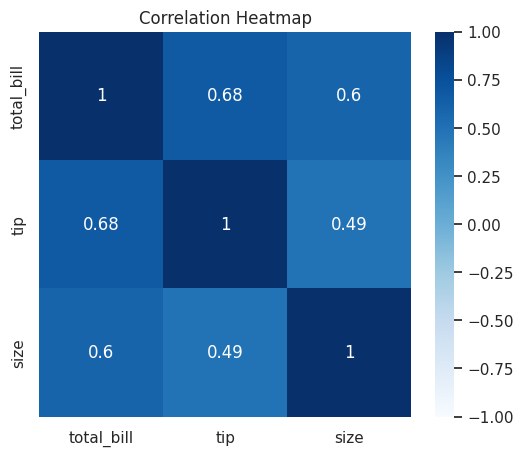


Statistical Summary:
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000


In [16]:
# LAB EXERCISE 5 - Correlation & Full Summary

# 1. Correlation matrix
corr = df.corr(numeric_only=True)

print("Correlation Matrix:")
print(corr.round(2))


# 2. Correlation heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1)

plt.title("Correlation Heatmap")
plt.show()


# 3. Full statistical summary
print("\nStatistical Summary:")
print(df.describe())

